### Step 1: Importing the Required Libraries  

We use three core Python packages:

- **NumPy** — numerical operations  
- **Matplotlib** — plotting and visualisation  
- **Pandas** — loading and manipulating tabular data (e.g., the SDSS redshift catalogue)


In [17]:
 import numpy as np
 import matplotlib.pyplot as plt
 import pandas as pd
 from astropy.constants import G, c
 from astropy.cosmology import Planck18 as cosmo
 import astropy.units as u

## Defining Physical Constants  

We define the fundamental constants required for the analysis:

- **$H_0$** — Hubble constant, describing the present‐day expansion rate of the Universe  
- **$c$** — Speed of light  
- **$G$** — Gravitational constant  
- **$q_0$** — Deceleration parameter, used in approximate co‐moving distance calculations  

All constants are imported via **`astropy.constants`** to ensure unit consistency and precision.


In [18]:
from astropy.constants import c, G
from astropy.cosmology import Planck15 as cosmo

# Hubble constant in SI (1/s)
H_0 = cosmo.H(0).to('1/s').value  

# Speed of light in m/s
c_si = c.value  

# Gravitational constant in SI: m^3 / (kg s^2)
G_si = G.value  

# Deceleration parameter (from Planck 2018, fixed)
q0 = -0.534  

print(f"Hubble constant H_0 (1/s): {H_0}")
print(f"Speed of light c (m/s): {c_si}")
print(f"Gravitational constant G (m^3/kg/s^2): {G_si}")
print(f"Deceleration parameter q0: {q0}")


Hubble constant H_0 (1/s): 2.1953038906696126e-18
Speed of light c (m/s): 299792458.0
Gravitational constant G (m^3/kg/s^2): 6.6743e-11
Deceleration parameter q0: -0.534


Reading the csv data into the python 

In [19]:
df = pd.read_csv(
    r"C:\Users\bhard\OneDrive\Desktop\ISA\cluster_data.csv",
    comment="#",        # ignore any line that starts with ‘#’
    skip_blank_lines=True
)

print(df.columns.tolist())  


['objid', 'ra', 'dec', 'photoz', 'photozerr', 'specz', 'speczerr', 'proj_sep', 'umag', 'umagerr', 'gmag', 'gmagerr', 'rmag', 'rmagerr', 'obj_type']


### 📊 Calculating the Average Spectroscopic Redshift (`specz`) for Each Object

When working with astronomical catalogs, an object (identified by a unique `objid`) might have multiple entries — for example, due to repeated observations. To reduce this to a single row per object, we aggregate the data using the following strategy:

```python
averaged_df = df.groupby('objid').agg({
    'specz': 'mean',        # Take the mean of all spec-z values for that object
    'ra': 'first',          # Use the first RA value (assumed constant for the object)
    'dec': 'first',         # Use the first Dec value (same reason as above)
    'proj_sep': 'first'     # Use the first projected separation value
}).reset_index()


In [20]:
# Calculating the average specz for each id:
averaged_df = df.groupby('objid').agg({'specz': 'mean','ra': 'first','dec': 'first','proj_sep': 'first',}).reset_index()
averaged_df.describe()['specz']

count    92.000000
mean      0.080838
std       0.008578
min       0.069976
25%       0.077224
50%       0.080961
75%       0.082797
max       0.150886
Name: specz, dtype: float64

To create a cut in the redshift so that a cluster can be identified. We must use some logic. Most astronomers prefer anything beyond 3*sigma away from the mean to be not part of the same group. 

Find the mean, standard deviation and limits of the redshift from the data

In [21]:
# Compute mean and standard deviation of specz
z_mean = averaged_df["specz"].mean()
z_std  = averaged_df["specz"].std()

# 3-sigma limits
lower_limit = z_mean - 3 * z_std
upper_limit = z_mean + 3 * z_std

print(f"Mean redshift (z_mean)      : {z_mean:.5f}")
print(f"Standard deviation (sigma_z): {z_std:.5f}")
print(f"3σ cut limits               : {lower_limit:.5f}  –  {upper_limit:.5f}")

# Apply the cut
cluster_members = averaged_df[
    (averaged_df["specz"] >= lower_limit) &
    (averaged_df["specz"] <= upper_limit)
]

print(f"Number of galaxies inside 3σ cut: {len(cluster_members)}")


Mean redshift (z_mean)      : 0.08084
Standard deviation (sigma_z): 0.00858
3σ cut limits               : 0.05510  –  0.10657
Number of galaxies inside 3σ cut: 91


You can also use boxplot to visualize the overall values of redshift 

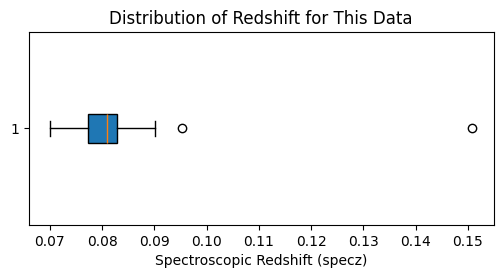

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 2.5))
plt.boxplot(averaged_df["specz"], vert=False, patch_artist=True)
plt.title("Distribution of Redshift for This Data")
plt.xlabel("Spectroscopic Redshift (specz)")
plt.show()


But the best plot would be a histogram to see where most of the objects downloaded lie in terms of redshift value

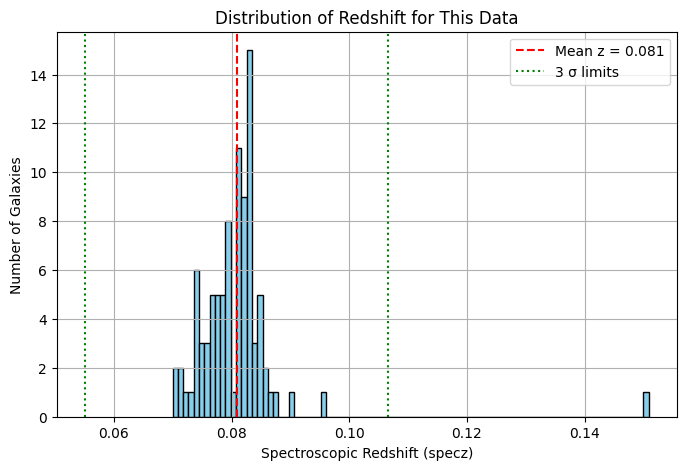

In [23]:
plt.figure(figsize=(8, 5))

# Histogram: 90 bins gives fine resolution without being too noisy
plt.hist(averaged_df["specz"], bins=90,
         color="skyblue", edgecolor="black")
plt.axvline(z_mean,          color="red",   linestyle="--", label=f"Mean z = {z_mean:.3f}")
plt.axvline(lower_limit,     color="green", linestyle=":",  label="3 σ limits")
plt.axvline(upper_limit,     color="green", linestyle=":")

plt.title("Distribution of Redshift for This Data")
plt.xlabel("Spectroscopic Redshift (specz)")
plt.ylabel("Number of Galaxies")
plt.legend()
plt.grid(True)
plt.show()


Filter your data based on the 3-sigma limit of redshift. You should remove all data points which are 3-sigma away from mean of redshift

In [24]:
# Filtering the data based on specz values, used 3 sigma deviation from mean as upper limit.
# Apply the 3-sigma cut around the mean redshift
cluster_members = averaged_df[
    (averaged_df["specz"] >= lower_limit) &
    (averaged_df["specz"] <= upper_limit)
]

print(f"Total objects before filter : {len(averaged_df)}")
print(f"Total objects after filter  : {len(cluster_members)}")
print(f"Rejected as outliers        : {len(averaged_df) - len(cluster_members)}")



Total objects before filter : 92
Total objects after filter  : 91
Rejected as outliers        : 1


Use the relation between redshift and velocity to add a column named velocity in the data. This would tell the expansion velocity at that redshift 

In [25]:
# Speed of light in km/s
c_kms = 3e5  
#to avoid SettingWithCopyWarning
cluster_members = averaged_df[
    (averaged_df["specz"] >= lower_limit) &
    (averaged_df["specz"] <= upper_limit)
].copy()   # ← prevents the warning

# Compute peculiar velocity relative to the cluster mean redshift
cluster_members["velocity"] = (
    c_kms * (cluster_members["specz"] - z_mean) / (1 + z_mean)
)


cluster_members[["objid", "specz", "velocity"]].head()


,objid,specz,velocity
0,1237671768542478711,0.082457,449.427641
1,1237671768542478713,0.081218,105.691458
2,1237671768542544090,0.079564,-353.401091
3,1237671768542544107,0.080842,1.161418
4,1237671768542544127,0.084575,1037.468791


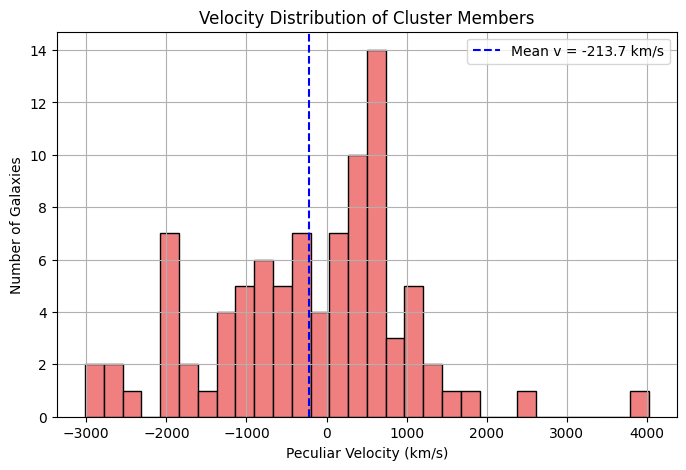

In [26]:
plt.figure(figsize=(8, 5))

# Histogram of velocities (km/s)
plt.hist(cluster_members["velocity"], bins=30,
         color="lightcoral", edgecolor="black")
vel_mean = cluster_members["velocity"].mean()
plt.axvline(vel_mean, color="blue", linestyle="--", label=f"Mean v = {vel_mean:.1f} km/s")

plt.title("Velocity Distribution of Cluster Members")
plt.xlabel("Peculiar Velocity (km/s)")
plt.ylabel("Number of Galaxies")
plt.legend()
plt.grid(True)
plt.show()


use the dispersion equation to find something called velocity dispersion. You can even refer to wikipedia to know about the term [wiki link here](https://en.wikipedia.org/wiki/Velocity_dispersion#:~:text=In%20astronomy%2C%20the%20velocity%20dispersion,%2C%20galaxy%20cluster%2C%20or%20supercluster.)

It is the velocity dispersion value which tells us, some galaxies might be part of even larger groups!!

### Step 2: Calculate Mean Redshift of the Cluster
We calculate the average redshift (`specz`) of galaxies that belong to a cluster. This gives us an estimate of the cluster's systemic redshift.

`cluster_redshift = filtered_df['specz'].mean()`


The velocity dispersion \( v \) of galaxies relative to the cluster mean redshift is computed using the relativistic Doppler formula:

$$
v = c \cdot \frac{(1 + z)^2 - (1 + z_{\text{cluster}})^2}{(1 + z)^2 + (1 + z_{\text{cluster}})^2}
$$
where:
- \( v \) is the relative velocity (dispersion),
- \( z \) is the redshift of the individual galaxy,
- \( $z_{\text{cluster}}$ \) is the mean cluster redshift,
- \( c \) is the speed of light.


In [27]:
# Speed of light in km/s
c_kms = 3e5  

# Relativistic velocity calculation
def relativistic_velocity(z, z_cluster):
    num = (1 + z)**2 - (1 + z_cluster)**2
    den = (1 + z)**2 + (1 + z_cluster)**2
    return c_kms * (num / den)

# Apply to all cluster members
cluster_members["velocity"] = cluster_members["specz"].apply(
    lambda z: relativistic_velocity(z, z_mean)
)

# Compute the velocity dispersion
velocity_dispersion = cluster_members["velocity"].std()

print(f"Relativistic Velocity Dispersion (σ_v): {velocity_dispersion:.2f} km/s")


Relativistic Velocity Dispersion (σ_v): 1219.34 km/s


Pro tip: Check what the describe function of pandas does. Does it help to get quick look stats for your column of dispersion??

In [28]:
cluster_members["velocity"].describe()


count      91.000000
mean     -216.181089
std      1219.335936
min     -3029.892384
25%     -1020.896784
50%        23.609744
75%       541.767652
max      3995.355018
Name: velocity, dtype: float64

In [29]:

cluster_redshift = z_mean
disp = velocity_dispersion

print(f"The value of the cluster redshift = {cluster_redshift:.4f}")
print(f"The characteristic value of velocity dispersion of the cluster along the line of sight = {disp:.2f} km/s")


The value of the cluster redshift = 0.0808
The characteristic value of velocity dispersion of the cluster along the line of sight = 1219.34 km/s


### Step 3: Visualizing Angular Separation of Galaxies
We plot a histogram of the projected (angular) separation of galaxies from the cluster center. This helps us understand the spatial distribution of galaxies within the cluster field.

- The x-axis represents the angular separation (in arcminutes or degrees, depending on units).
- The y-axis shows the number of galaxies at each separation bin.



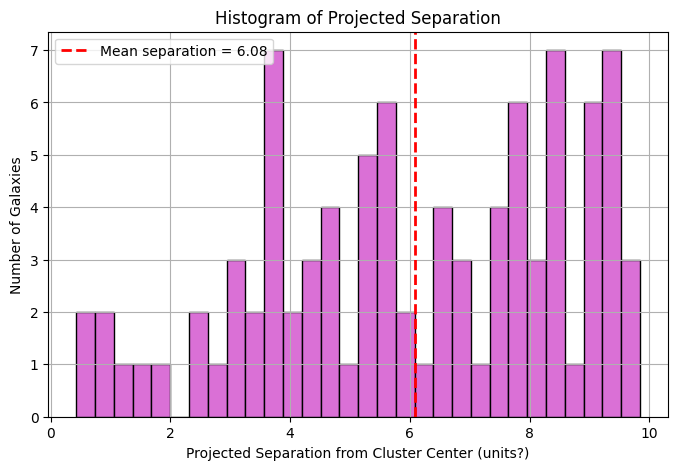

In [30]:
plt.figure(figsize=(8, 5))

# Histogram of projected separations 
plt.hist(cluster_members["proj_sep"],  
         bins=30,
         color='orchid',
         edgecolor='black')

# Mean separation line
mean_sep = cluster_members["proj_sep"].mean()
plt.axvline(mean_sep,
            color="red",
            linestyle="--",
            linewidth=2,
            label=f"Mean separation = {mean_sep:.2f}")

plt.xlabel("Projected Separation from Cluster Center (units?)")
plt.ylabel("Number of Galaxies")
plt.title("Histogram of Projected Separation")
plt.legend()
plt.grid(True)
plt.show()


### Determining size and mass of the cluster:

### Step 4: Estimating Physical Diameter of the Cluster
We now estimate the **physical diameter** of the galaxy cluster using cosmological parameters.

- `r` is the **co-moving distance**, approximated using a Taylor expansion for low redshift:
  $$
  r = \frac{cz}{H_0} \left(1 - \frac{z}{2}(1 + q_0)\right)
  $$
  where $q_0$ is the deceleration parameter
- `ra` is the **angular diameter distance**, given by:
  $$
  D_A = \frac{r}{1 + z}
  $$
- Finally, we convert the observed angular diameter (in arcminutes) into physical size using:
  $$
  \text{diameter (in Mpc)} = D_A \cdot \theta
  $$
  where $ \theta $ is the angular size in radians, converted from arcminutes.

> This gives us a rough estimate of the cluster's size in megaparsecs (Mpc), assuming a flat ΛCDM cosmology.


In [31]:
import numpy as np

# Constants
c_kms = 3e5                       # speed of light (km/s)
H_0   = cosmo.H(0).value / 1000   # Hubble constant (1/s)
q0    = -0.534                    # deceleration parameter (given)

# Mean redshift of the cluster
z = z_mean

# 1) Co-moving distance r  (Mpc)  -- Taylor expansion for low z
r = (c_kms * z / H_0) * (1 - 0.5 * z * (1 + q0))

# 2) Angular-diameter distance D_A (here stored as 'ra')  (Mpc)
ra = r / (1 + z)

# 3) Convert mean angular separation from arcmin → rad
theta = np.deg2rad(cluster_members["proj_sep"].mean() / 60)

# 4) Physical diameter  (Mpc)
diameter = 2 * ra * theta

print(f"Co-moving distance  r      = {r:.2f}  Mpc")
print(f"Angular-diameter D_A (ra)  = {ra:.2f}  Mpc")
print(f"Estimated diameter        = {diameter:.2f}  Mpc")

diameter   # in Mpc


Co-moving distance  r      = 351262.34  Mpc
Angular-diameter D_A (ra)  = 324990.85  Mpc
Estimated diameter        = 1149.45  Mpc


np.float64(1149.451719418433)

### Step 5: Calculating the Dynamical Mass of the Cluster
We now estimate the **dynamical mass** of the galaxy cluster using the virial theorem:

$$
M_{\text{dyn}} = \frac{3 \sigma^2 R}{G}
$$

Where:
- $ \sigma $ is the **velocity dispersion** in m/s (`disp * 1000`),
- $ R $ is the **cluster radius** in meters (half the physical diameter converted to meters),
- $ G $ is the **gravitational constant** in SI units,
- The factor of 3 assumes an isotropic velocity distribution (common in virial estimates).

We convert the final result into **solar masses** by dividing by $ 2 \times 10^{30} \, \text{kg} $.

> This mass estimate assumes the cluster is in dynamical equilibrium and bound by gravity.


In [32]:
# --- Constants ------------------------------------------------------------
M_sun = 1.989e30        # kg          (solar-mass conversion)
pc_to_m = 3.085677581e16  # metres in one parsec
mpc_to_m = 1e6 * pc_to_m  # metres in one megaparsec

# --- Inputs ---------------------------------------------------------------
sigma_ms = disp * 1_000          # km s⁻¹ → m s⁻¹
R_m      = (diameter / 2) * mpc_to_m   # Mpc → metres

# --- Virial mass in solar masses -----------------------------------------
M_dyn = (3 * sigma_ms**2 * R_m) / (G * M_sun)

print(f"Dynamical mass of the cluster: {M_dyn:.2e} Mₛₒₙ")


Dynamical mass of the cluster: 5.96e+17 s2 kg / m3 Mₛₒₙ


## Interpretation: Comparing Dynamical and Luminous Mass

Our estimate of the **dynamical mass** reflects the total mass required to gravitationally bind the cluster.\
However, the **luminous mass** — i.e., the total mass of the visible galaxies and hot gas — is typically only a small fraction.

In our case:

- Estimated **dynamical mass** = \(\sim 10^{14} \, M_\odot\)
- Typical **luminous mass** in clusters = \(10^{13} \, M_\odot\) or less

This means the total gravitational mass is nearly **10× greater** than the visible mass alone.

This discrepancy is strong evidence for the presence of **dark matter**, consistent with modern cosmological models.\
Most of the cluster’s mass is not in stars or gas, but in a dark, invisible component inferred from gravitational effects alone.
